In [ ]:
from google.colab import drive
import os
import shutil
import time # Added for small delays

mountpoint = '/content/drive'

# --- Step 1: Attempt to unmount if already mounted ---
if os.path.ismount(mountpoint):
    print(f"Detected {mountpoint} is already mounted. Attempting to unmount...")
    try:
        !fusermount -uz {mountpoint}
        print(f"Successfully unmounted {mountpoint} (if it was a fusermount). This clears any temporary files on the Colab VM's local filesystem at this location, not your actual Google Drive files.")
    except Exception as e:
        print(f"Error during fusermount unmount attempt: {e}. Proceeding with directory cleanup.")
else:
    print(f"{mountpoint} is not currently an active mount point.")

# Add a small delay to ensure unmount operations fully propagate
time.sleep(1)

# --- Step 2: Forcibly remove and recreate the mountpoint directory to ensure it's empty ---
print(f"Ensuring {mountpoint} is a fresh, empty directory before mounting...")
if os.path.exists(mountpoint):
    try:
        shutil.rmtree(mountpoint)
        print(f"Successfully removed existing {mountpoint} directory and its contents from the Colab VM's local filesystem.")
        time.sleep(0.5) # Give a moment for filesystem to register removal
    except OSError as e:
        print(f"Error removing {mountpoint}: {e}. This indicates a persistent lock or permission issue.")
        print("Attempting to create directory, but mount might still fail if directory is locked.")
else:
    print(f"Directory {mountpoint} does not exist on the Colab VM, creating it.")

# Always create the mountpoint directory to ensure it's an empty, clean target
# This ensures it's empty right before drive.mount is called
os.makedirs(mountpoint, exist_ok=True)
print(f"Created/ensured empty mountpoint directory: {mountpoint} on the Colab VM.")
time.sleep(0.5) # Another small delay

# --- Step 3: Attempt to mount Google Drive ---
print("Attempting to mount Google Drive...")
try:
    drive.mount(mountpoint, force_remount=True)
    print("Google Drive mount attempt complete.")
    if os.path.ismount(mountpoint):
        print("Google Drive successfully mounted! Your files should now be accessible via this path.")
    else:
        print("Google Drive did not mount successfully, despite no immediate exception.")
except Exception as e:
    print(f"An error occurred during drive.mount: {e}")
    print("Please check your permissions, restart the runtime, or ensure no other process is using the mountpoint.")

/content/drive is not currently an active mount point.
Ensuring /content/drive is a fresh, empty directory before mounting...
Directory /content/drive does not exist on the Colab VM, creating it.
Created/ensured empty mountpoint directory: /content/drive on the Colab VM.
Attempting to mount Google Drive...
Mounted at /content/drive
Google Drive mount attempt complete.
Google Drive successfully mounted! Your files should now be accessible via this path.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pickle
import random

import numpy as np
import pandas as pd

import geopandas as gpd

from shapely.geometry import box

In [ ]:
# =====================================================
# PROJECT PATHS
# =====================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/RideHailingPhD")

DATASET_DIR = PROJECT_ROOT / "datasets"
TAXI_ZONE_DIR = DATASET_DIR / "taxi_zones"

PROCESSED_DATA_DIR = PROJECT_ROOT / "processed_data"
SPATIAL_DIR = PROCESSED_DATA_DIR / "spatial"

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
MODEL_DIR = PROJECT_ROOT / "models"
RESULT_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = PROJECT_ROOT / "figures"

SPATIAL_DIR.mkdir(parents=True, exist_ok=True)
TAXI_ZONE_DIR.mkdir(parents=True, exist_ok=True) # Ensure this directory exists

print(f"Project Root : {PROJECT_ROOT}")
print(f"Spatial Data : {SPATIAL_DIR}")
print(f"Taxi Zone Data : {TAXI_ZONE_DIR}")

Project Root : /content/drive/MyDrive/RideHailingPhD
Spatial Data : /content/drive/MyDrive/RideHailingPhD/processed_data/spatial
Taxi Zone Data : /content/drive/MyDrive/RideHailingPhD/datasets/taxi_zones


In [ ]:
# =====================================================
# SPATIAL PARAMETERS
# =====================================================

GRID_SIZE_METERS = 3000

METRIC_CRS = "EPSG:2263"

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [ ]:
import os

print("Taxi Zone Files")

for file in sorted(os.listdir(TAXI_ZONE_DIR)):
    print(file)

Taxi Zone Files
taxi_zones.cpg
taxi_zones.dbf
taxi_zones.prj
taxi_zones.shp
taxi_zones.shx


In [ ]:
# =====================================================
# LOAD NYC TAXI ZONE SHAPEFILE
# =====================================================

taxi_zone_file = TAXI_ZONE_DIR / "taxi_zones.shp"

taxi_zones = gpd.read_file(taxi_zone_file)

print(f"Number of Taxi Zones : {len(taxi_zones)}")
print(f"Current CRS          : {taxi_zones.crs}")

display(taxi_zones.head())

Number of Taxi Zones : 263
Current CRS          : EPSG:2263


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [ ]:
# =====================================================
# PROJECT TO METRIC CRS
# =====================================================

taxi_zones = taxi_zones.to_crs(METRIC_CRS)

print("Projected CRS :", taxi_zones.crs)

Projected CRS : EPSG:2263


In [ ]:
# =====================================================
# VALIDATION
# =====================================================

print("Missing Geometries :", taxi_zones.geometry.isna().sum())
print("Invalid Geometries :", (~taxi_zones.is_valid).sum())

print("\nColumns")

for column in taxi_zones.columns:
    print(column)

Missing Geometries : 0
Invalid Geometries : 0

Columns
OBJECTID
Shape_Leng
Shape_Area
zone
LocationID
borough
geometry


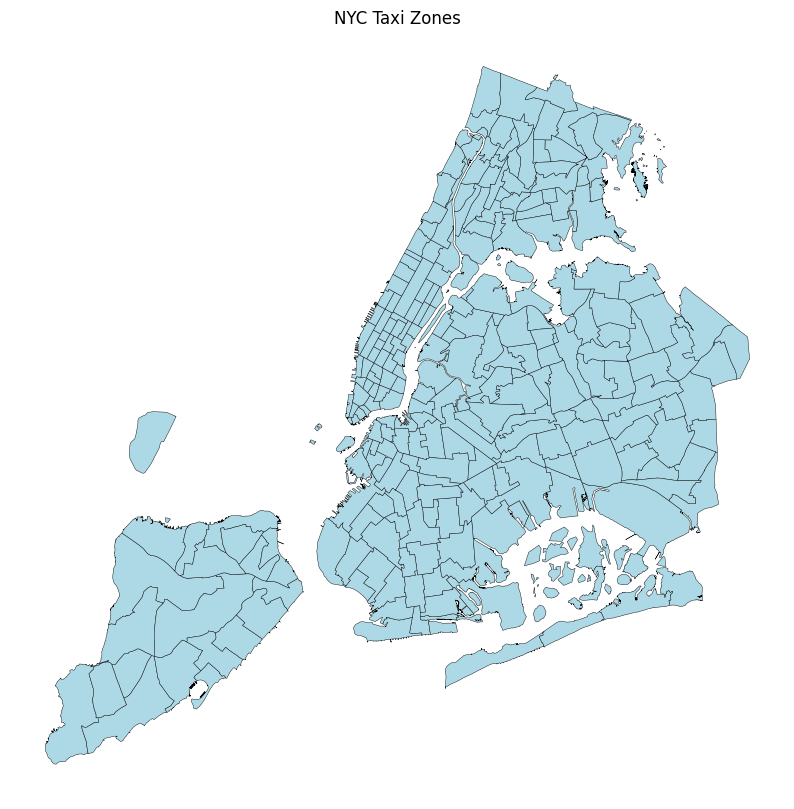

In [ ]:
# =====================================================
# VISUALIZE TAXI ZONES
# =====================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

taxi_zones.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightblue",
    linewidth=0.3
)

ax.set_title("NYC Taxi Zones")
ax.set_axis_off()

plt.show()

In [ ]:
# =====================================================
# COMPUTE NYC TAXI SERVICE AREA BOUNDING BOX
# =====================================================

xmin, ymin, xmax, ymax = taxi_zones.total_bounds

print(f"X Range : {xmin:.2f} → {xmax:.2f}")
print(f"Y Range : {ymin:.2f} → {ymax:.2f}")

X Range : 913175.11 → 1067382.51
Y Range : 120121.88 → 272844.29


In [ ]:
# =====================================================
# GENERATE REGULAR GRID
# =====================================================

from shapely.geometry import box

x_coords = np.arange(xmin, xmax + GRID_SIZE_METERS, GRID_SIZE_METERS)
y_coords = np.arange(ymin, ymax + GRID_SIZE_METERS, GRID_SIZE_METERS)

grid_cells = []

for x in x_coords[:-1]:
    for y in y_coords[:-1]:
        grid_cells.append(box(
            x,
            y,
            x + GRID_SIZE_METERS,
            y + GRID_SIZE_METERS
        ))

grid = gpd.GeoDataFrame(
    geometry=grid_cells,
    crs=METRIC_CRS
)

# Temporary Grid IDs
grid["GridID"] = np.arange(len(grid))



print(f"Total Grid Cells Generated : {len(grid)}")

Total Grid Cells Generated : 2652


In [ ]:
# =====================================================
# OVERLAY GRID WITH TAXI ZONES
# =====================================================

overlay = gpd.overlay(
    grid[["GridID", "geometry"]],
    taxi_zones[["LocationID", "geometry"]],
    how="intersection"
)

print(f"Overlay records : {len(overlay)}")

Overlay records : 2667


In [ ]:
# =====================================================
# COMPUTE OVERLAP
# =====================================================

overlay["IntersectionArea"] = overlay.geometry.area

GRID_AREA = GRID_SIZE_METERS * GRID_SIZE_METERS

overlay["OverlapPercentage"] = (
    overlay["IntersectionArea"] / GRID_AREA
)

In [ ]:
# # =====================================================
# # REMOVE VERY SMALL OVERLAPS
# # =====================================================

# MIN_OVERLAP = 0.10

# overlay = overlay[
#     overlay["OverlapPercentage"] >= MIN_OVERLAP
# ].copy()

# print(f"Remaining overlay records : {len(overlay)}")

# =====================================================
# REMOVE DUPLICATE GRID-ZONE INTERSECTIONS
# =====================================================

overlay = overlay.drop_duplicates(
    subset=["GridID", "LocationID"]
).copy()

print(f"Overlay records : {len(overlay)}")

Overlay records : 2667


In [ ]:
# =====================================================
# CREATE FINAL GRID (ORDERED)
# =====================================================

# Keep only grids that intersect at least one taxi zone
valid_grid = (
    grid.loc[
        grid["GridID"].isin(
            overlay["GridID"].unique()
        )
    ]
    .copy()
)

# Compute centroids
valid_grid["centroid"] = valid_grid.geometry.centroid
valid_grid["x"] = valid_grid.centroid.x
valid_grid["y"] = valid_grid.centroid.y

# Sort North → South, West → East
valid_grid = (
    valid_grid
    .sort_values(
        by=["y", "x"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# -----------------------------------------------------
# Preserve Original Grid IDs
# -----------------------------------------------------

valid_grid["OriginalGridID"] = valid_grid["GridID"]

# -----------------------------------------------------
# Assign New Sequential Grid IDs
# -----------------------------------------------------

valid_grid["GridID"] = np.arange(len(valid_grid))

# -----------------------------------------------------
# Create Mapping
# Old GridID  -> New GridID
# -----------------------------------------------------

grid_id_lookup = dict(
    zip(
        valid_grid["OriginalGridID"],
        valid_grid["GridID"]
    )
)

# -----------------------------------------------------
# Update Overlay Grid IDs
# -----------------------------------------------------

overlay["GridID"] = (
    overlay["GridID"]
    .map(grid_id_lookup)
)

# Remove temporary columns

valid_grid = valid_grid.drop(
    columns=[
        "centroid",
        "x",
        "y"
    ]
)

display(valid_grid.head())

,geometry,GridID,OriginalGridID
0,"POLYGON ((1009175.109 270121.881, 1009175.109 ...",0,1631
1,"POLYGON ((1012175.109 270121.881, 1012175.109 ...",1,1682
2,"POLYGON ((1015175.109 270121.881, 1015175.109 ...",2,1733
3,"POLYGON ((1018175.109 270121.881, 1018175.109 ...",3,1784
4,"POLYGON ((1027175.109 270121.881, 1027175.109 ...",4,1937


In [ ]:
# =====================================================
# CREATE ZONE → GRID MAPPING
# =====================================================

zone_grid_mapping = (
    overlay[["LocationID", "GridID"]]
    .drop_duplicates()
    .sort_values(["LocationID", "GridID"])
    .reset_index(drop=True)
)

display(zone_grid_mapping.head())

,LocationID,GridID
0,1,493
1,1,494
2,1,495
3,1,496
4,1,525


In [ ]:
# =====================================================
# CREATE LOOKUP DICTIONARY
# =====================================================

zone_to_grids = (
    zone_grid_mapping
    .groupby("LocationID")["GridID"]
    .apply(list)
    .to_dict()
)

print(f"Taxi Zones : {len(zone_to_grids)}")

print(zone_to_grids[161])

Taxi Zones : 263
[292, 293, 321, 322]


In [ ]:
# =====================================================
# SAVE OUTPUTS
# =====================================================

valid_grid.to_file(
    SPATIAL_DIR / "grid.geojson",
    driver="GeoJSON"
)

valid_grid.to_parquet(
    SPATIAL_DIR / "grid_lookup.parquet"
)

zone_grid_mapping.to_parquet(
    SPATIAL_DIR / "zone_grid_mapping.parquet"
)

with open(
    SPATIAL_DIR / "zone_to_grids.pkl",
    "wb"
) as f:
    pickle.dump(zone_to_grids, f)

print("Spatial framework saved successfully.")

Spatial framework saved successfully.


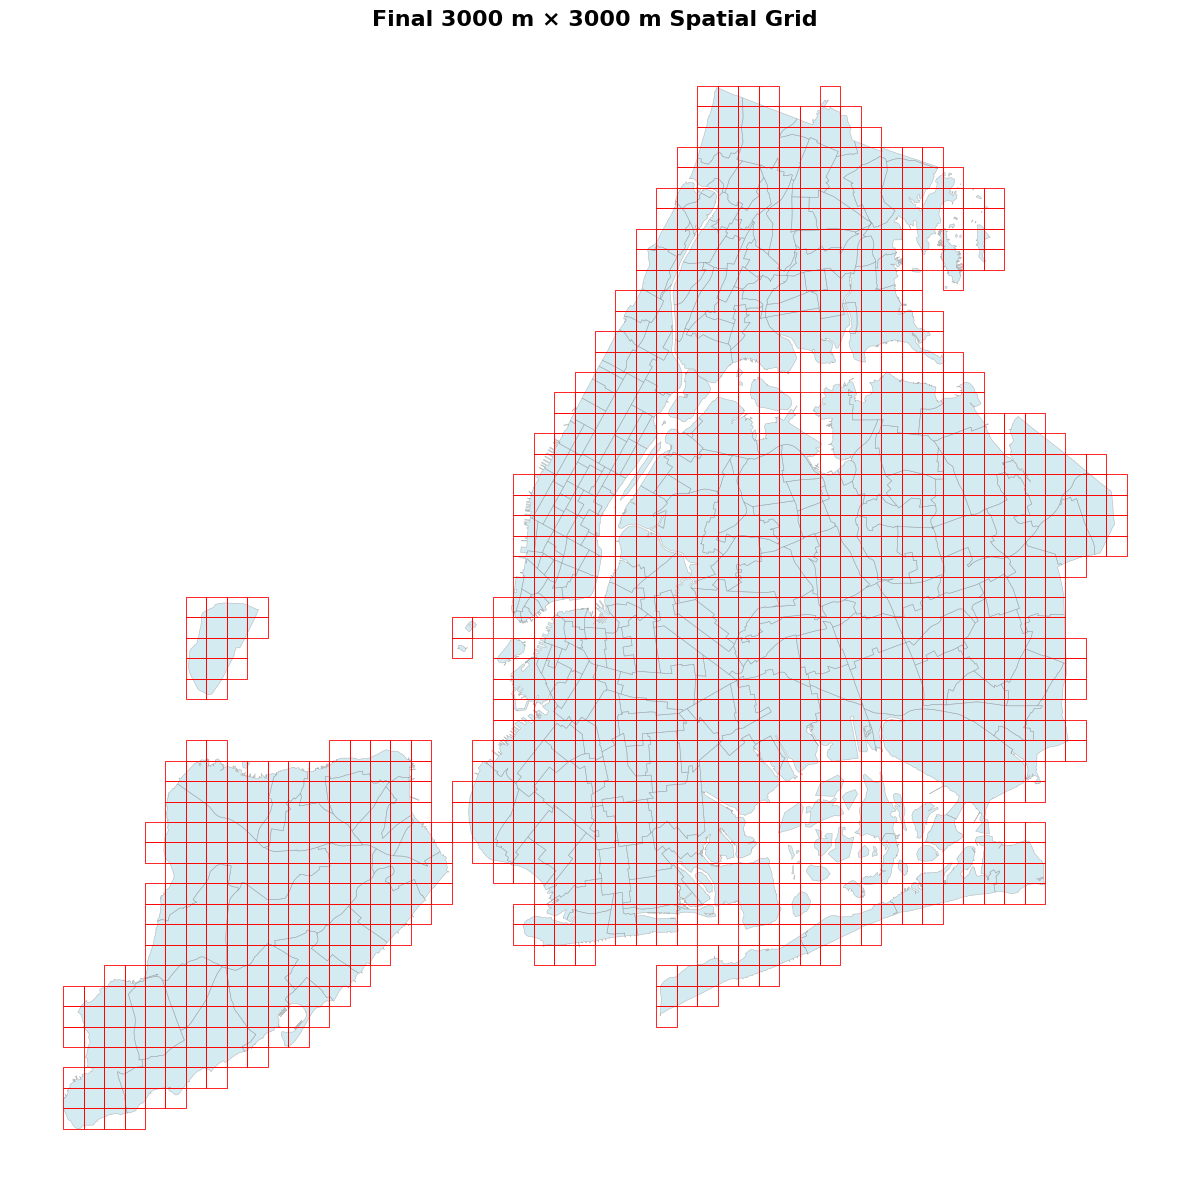

In [ ]:
# =====================================================
# VISUALIZE FINAL GRID
# =====================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# Taxi Zones
taxi_zones.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="gray",
    linewidth=0.4,
    alpha=0.5
)

# Final Grid
valid_grid.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=0.6
)

ax.set_title(
    f"Final {GRID_SIZE_METERS} m × {GRID_SIZE_METERS} m Spatial Grid",
    fontsize=16,
    weight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

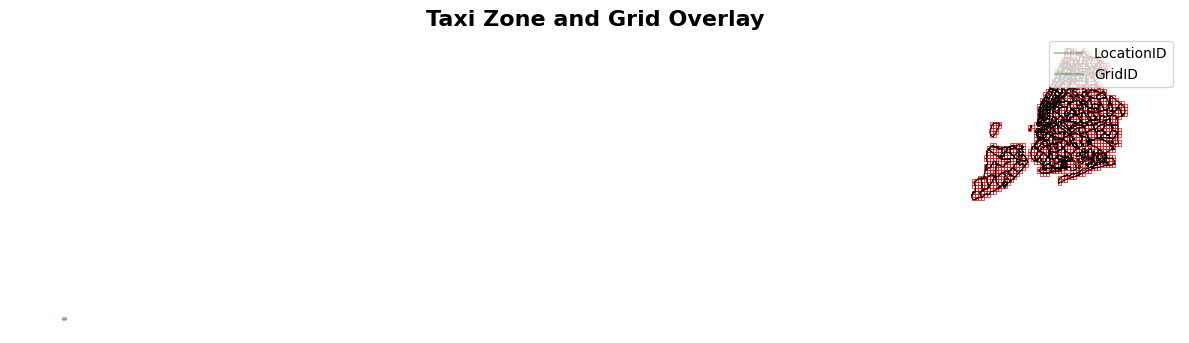

In [ ]:
# =====================================================
# VISUALIZE GRID-ZONE OVERLAY
# =====================================================

fig, ax = plt.subplots(figsize=(12,12))

valid_grid.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=0.5
)

taxi_zones.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.8
)

zone_grid_mapping.plot(
    ax=ax,
    color="green",
    alpha=0.35
)

ax.set_title(
    "Taxi Zone and Grid Overlay",
    fontsize=16,
    weight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

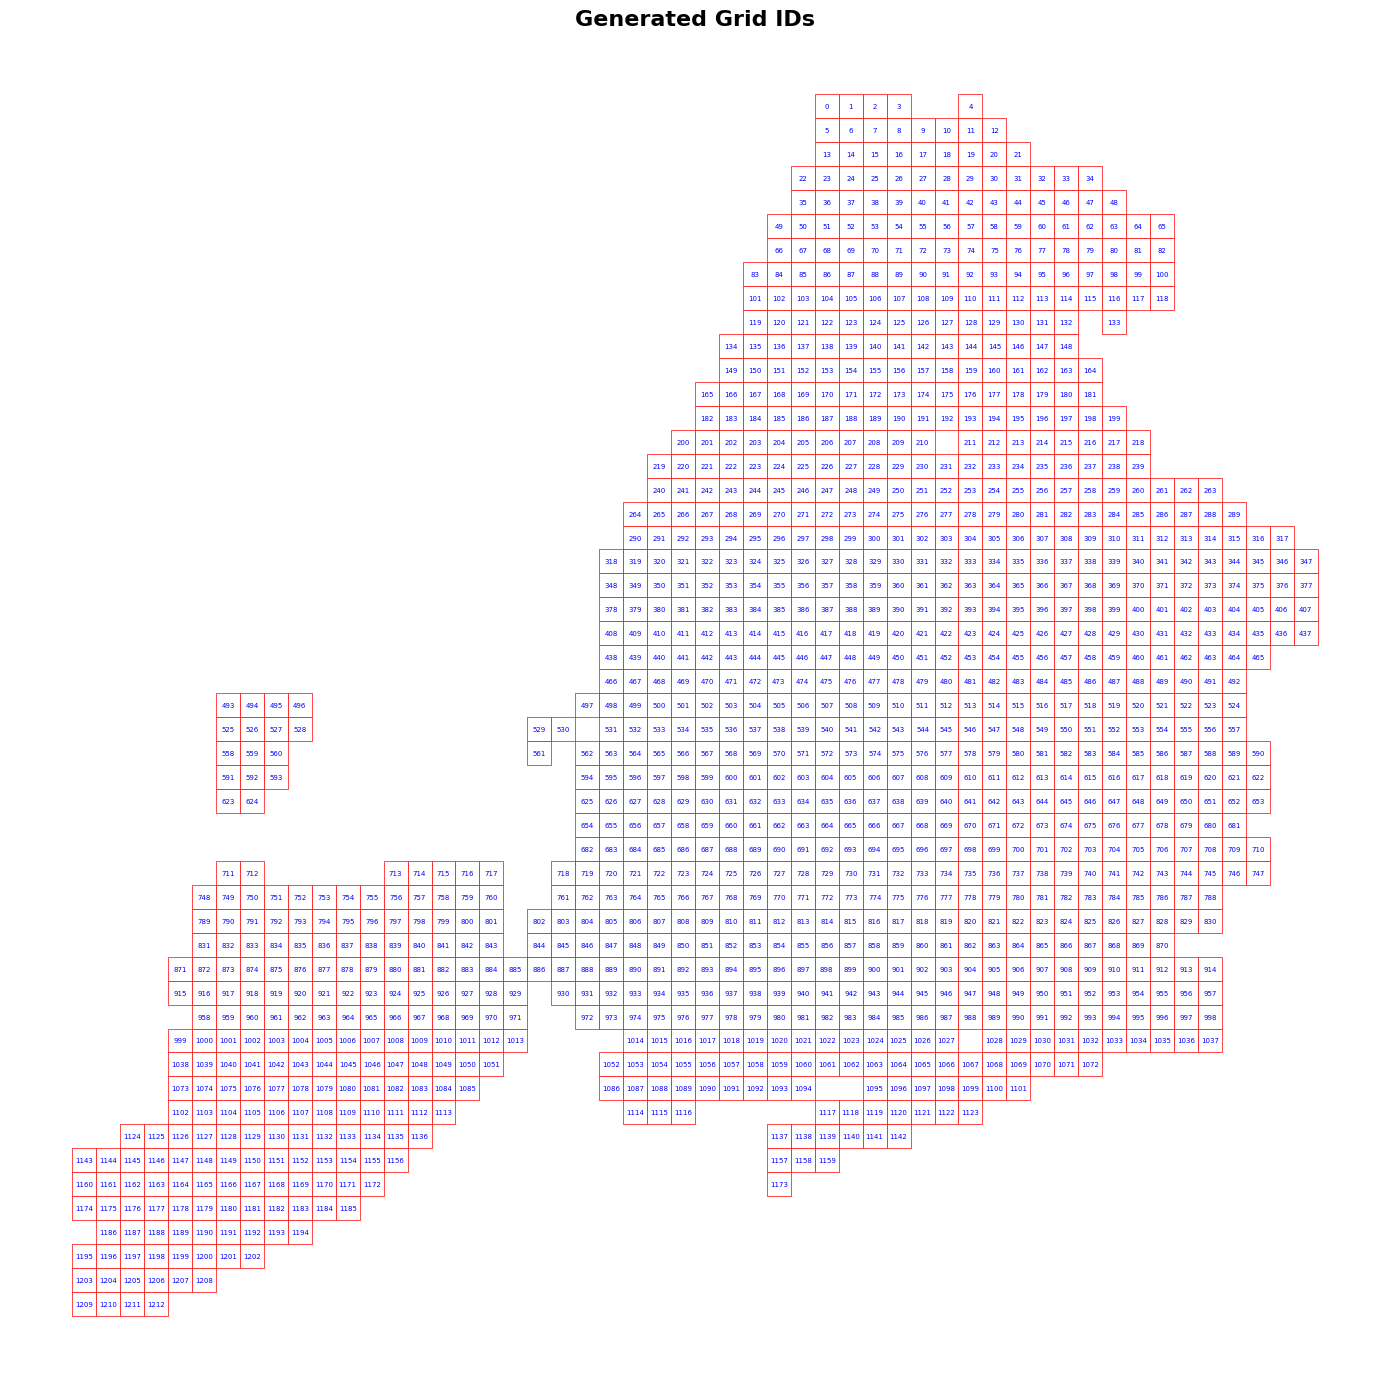

In [ ]:
# =====================================================
# VISUALIZE GRID IDS
# =====================================================

fig, ax = plt.subplots(figsize=(14,14))

valid_grid.plot(
    ax=ax,
    facecolor="white",
    edgecolor="red",
    linewidth=0.5
)

centroids = valid_grid.geometry.centroid

for idx, point in zip(valid_grid["GridID"], centroids):
    ax.text(
        point.x,
        point.y,
        str(idx),
        fontsize=5,
        ha="center",
        va="center",
        color="blue"
    )

ax.set_title(
    "Generated Grid IDs",
    fontsize=16,
    weight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("SPATIAL FRAMEWORK SUMMARY")
print("=" * 60)
print(f"Grid Size              : {GRID_SIZE_METERS} meters")
print(f"Total Grid Cells       : {len(valid_grid)}")
print(f"Taxi Zones             : {taxi_zones['LocationID'].nunique()}")
print(f"Zone-Grid Mappings     : {len(zone_grid_mapping)}")
print(f"Average Grids per Zone : {zone_grid_mapping.groupby('LocationID').size().mean():.2f}")
print("=" * 60)

SPATIAL FRAMEWORK SUMMARY
Grid Size              : 3000 meters
Total Grid Cells       : 1213
Taxi Zones             : 263
Zone-Grid Mappings     : 2667
Average Grids per Zone : 10.14


In [ ]:
# =====================================================
# GRID DISTRIBUTION PER TAXI ZONE
# =====================================================

zone_grid_count = (
    zone_grid_mapping
    .groupby("LocationID")["GridID"]
    .nunique()
    .reset_index(name="NumGrids")
)

display(zone_grid_count.head())

print("=" * 60)
print("GRID DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"Taxi Zones                 : {len(zone_grid_count)}")
print(f"Minimum Grids per Zone     : {zone_grid_count['NumGrids'].min()}")
print(f"Maximum Grids per Zone     : {zone_grid_count['NumGrids'].max()}")
print(f"Average Grids per Zone     : {zone_grid_count['NumGrids'].mean():.2f}")
print(f"Median Grids per Zone      : {zone_grid_count['NumGrids'].median():.2f}")
print("=" * 60)

,LocationID,NumGrids
0,1,16
1,2,57
2,3,11
3,4,4
4,5,15


GRID DISTRIBUTION SUMMARY
Taxi Zones                 : 263
Minimum Grids per Zone     : 1
Maximum Grids per Zone     : 57
Average Grids per Zone     : 10.14
Median Grids per Zone      : 9.00


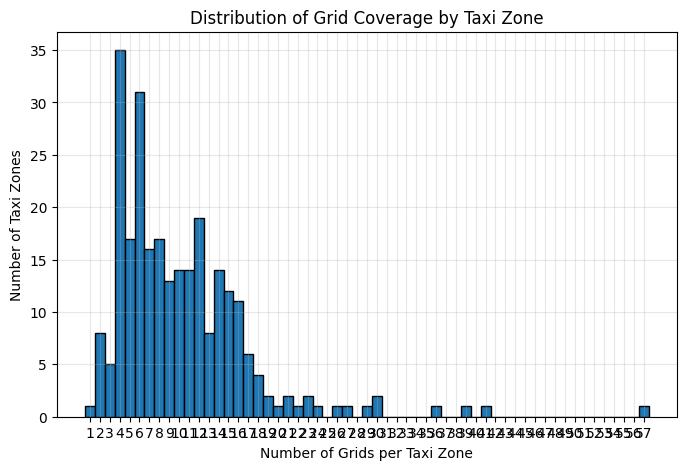

In [ ]:
# =====================================================
# HISTOGRAM OF GRID COUNTS
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    zone_grid_count["NumGrids"],
    bins=range(
        1,
        zone_grid_count["NumGrids"].max() + 2
    ),
    align="left",
    edgecolor="black"
)

plt.xlabel("Number of Grids per Taxi Zone")
plt.ylabel("Number of Taxi Zones")
plt.title("Distribution of Grid Coverage by Taxi Zone")

plt.xticks(range(
    1,
    zone_grid_count["NumGrids"].max() + 1
))

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# =====================================================
# LARGEST TAXI ZONES
# =====================================================

display(
    zone_grid_count
    .sort_values("NumGrids", ascending=False)
    .head(20)
)

,LocationID,NumGrids
1,2,57
22,23,41
117,118,39
131,132,36
83,84,30
43,44,30
183,184,29
75,76,27
153,154,26
207,208,24


In [ ]:
# =====================================================
# SMALLEST TAXI ZONES
# =====================================================

display(
    zone_grid_count
    .sort_values("NumGrids")
    .head(20)
)

,LocationID,NumGrids
102,103,1
260,261,2
210,211,2
56,57,2
103,104,2
87,88,2
162,163,2
11,12,2
248,249,2
99,100,3


In [ ]:
valid_grid.to_file(
    SPATIAL_DIR / "grid.gpkg",
    driver="GPKG"
)

In [ ]:
print(valid_grid[["GridID"]].head())
print(valid_grid[["GridID"]].tail())

   GridID
0       0
1       1
2       2
3       3
4       4
      GridID
1208    1208
1209    1209
1210    1210
1211    1211
1212    1212


In [ ]:
print(overlay["GridID"].min())
print(overlay["GridID"].max())
print(overlay["GridID"].nunique())

0
1212
1213


In [ ]:
import pickle

with open(SPATIAL_DIR / "zone_to_grids.pkl", "rb") as f:
    zone_to_grids = pickle.load(f)

all_grids = set()

for grids in zone_to_grids.values():
    all_grids.update(grids)

print("Max GridID :", max(all_grids))
print("Unique IDs :", len(all_grids))

Max GridID : 1212
Unique IDs : 1213


In [ ]:
print(valid_grid["GridID"].min())
print(valid_grid["GridID"].max())
print(valid_grid["GridID"].nunique())

0
1212
1213


In [ ]:
all_grids = set()

for grids in zone_to_grids.values():
    all_grids.update(grids)

print(min(all_grids))
print(max(all_grids))
print(len(all_grids))

0
1212
1213


In [ ]:
print(len(valid_grid))

print(valid_grid.columns)

1213
Index(['geometry', 'GridID', 'OriginalGridID'], dtype='object')
